In [1]:
import os
import sys
import shutil
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import kagglehub
from pathlib import Path

c:\Users\BIT\Desktop\Deep_Generative_Modelling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
current_dir = Path.cwd()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("done")

done


In [ ]:
# data_path = project_root / "data"
# cache_path = kagglehub.dataset_download("kundanbedmutha/exam-score-prediction-dataset")

# for item in Path(cache_path).iterdir():
#     shutil.copy2(item, data_path/item.name)
    
# print("Data Saved")

Data Saved


### So, I have got some data from kaggle and will try to apply higher dimension GMM on this data.

In [4]:
path = project_root / "data" / "Exam_Score_Prediction.csv"
data = pd.read_csv(str(path))

In [5]:
data.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


### For now I will try keep it simple and focus on only those features that not categorical.

In [6]:
data.shape

(20000, 13)

In [7]:
data.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [8]:
training_set = data.iloc[0: int(0.6*len(data))][['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']]
test_set = data.iloc[int(0.6*len(data)):][['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']]

In [9]:
training_set.head()

,age,study_hours,class_attendance,sleep_hours,exam_score
0,17,2.78,92.9,7.4,58.9
1,23,3.37,64.8,4.6,54.8
2,22,7.88,76.8,8.5,90.3
3,20,0.67,48.4,5.8,29.7
4,20,0.89,71.6,9.8,43.7


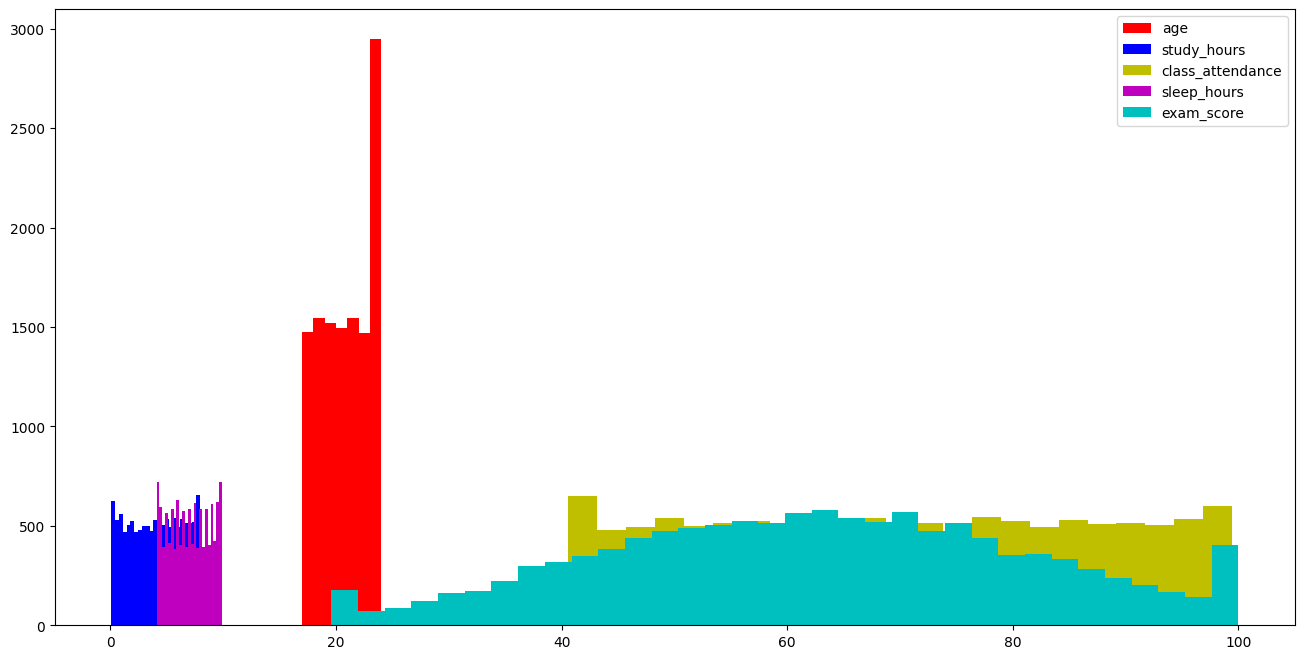

In [10]:
plt.figure(figsize=(16,8))
plt.hist(training_set["age"], color="r", bins='auto', label='age')
plt.hist(training_set["study_hours"], bins='auto', color='b', label='study_hours')
plt.hist(training_set["class_attendance"], color="y", bins='auto', label='class_attendance')
plt.hist(training_set["sleep_hours"], color='m', bins='auto', label='sleep_hours')
plt.hist(training_set["exam_score"], color='c', bins='auto', label='exam_score');

plt.legend()

So, Our data has 5 attributes and is coming from some k sources and we are assuming the every source is guassian and we have to estimate the parameters of those guassian sources

Step 1 we will start with initialization

In [11]:
dim = 5
k = 3
prior = 1/k
initial_means = (training_set.iloc[np.random.randint(low=0, high=len(training_set)-1, size=3)][["age", "study_hours", "class_attendance", 'sleep_hours', "exam_score"]]).to_numpy()
I = np.eye(5)
stacked_cov = np.stack([I, I, I], axis=0)

In [12]:
prior

0.3333333333333333

In [13]:
initial_means

array([[18.  ,  7.14, 90.  ,  7.6 , 79.6 ],
       [22.  ,  7.72, 81.  ,  4.6 , 97.3 ],
       [19.  ,  2.31, 71.3 ,  7.8 , 24.2 ]])

In [14]:
stacked_cov.shape

(3, 5, 5)

Step 2: Exceptation step - In this step we will use the our initial guess to calaculate the probabilities for each data point that which data point belongs to which source with what probability

In [15]:
def multivariate_normal_pdf(x: np.array, mean: np.array, cov: np.array):
    """Calculates the pdf for the multivariate normal distribution for given mean, cov and x

    Args:
        x (np.array): (N, d) array - N data points, d features
        mean (d, ) or (1, d): mean of the distribution(vector)
        cov (np.array): (d, d) cov matrix of the diatribution
    """
    N, d = x.shape
    det = np.linalg.det(cov)
    
    if det <= 1e-15:
        cov += np.eye(d) * 1e-6
        det = np.linalg.det(cov)
        
    inv_cov = np.linalg.inv(cov)
    
    diff = x - mean.reshape(1, -1)
    
    exponent = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
    
    log_normalization = -0.5 * (d * np.log(2 * np.pi) + np.log(det))
    
    return np.exp(log_normalization + exponent)

In [16]:
# Let's test it
prob = multivariate_normal_pdf(
        x=training_set.iloc[1:10].to_numpy(),
        mean=initial_means[0],
        cov=stacked_cov[0]
    )

In [17]:
prob

array([1.21291159e-284, 3.45519450e-069, 0.00000000e+000, 0.00000000e+000,
       2.01027198e-244, 1.18189097e-251, 0.00000000e+000, 3.40228529e-269,
       0.00000000e+000])

In [ ]:
# # Now when we have p(x/source) we can find the p(source/x) using bayes rule
# def bayes_prob(x: np.array, means: np.array, cov: np.array, source: int, prior: float = prior) -> float:
#     """Calculates the p(source/x) using bayes theorem

#     Args:
#         x (np.array): data point
#         means (np.array): means of the sources
#         cov (np.array): cov mat of the sources
#         source(int): which source(based on 0 indexing)

#     Returns:
#         float: p(source/x)
#     """
#     num = multivariate_normal_pdf(
#         x=x,
#         mean=means[source].reshape(5,1),
#         cov=cov[source]) * prior
    
#     deno = 0
#     for c in range(cov.shape[0]):
#         deno += multivariate_normal_pdf(
#         x=x,
#         mean=means[c].reshape(5,1),
#         cov=cov[c]) * prior
        
#     return num/deno

In [24]:
def bayes_probs(X: np.array, means: np.array, cov: np.array, prior: float = prior) -> np.array:
    """Gives the bayes_probs for all the sources in a array

    Args:
        X (np.array): data
        means (np.array): means of the sources
        cov (np.array): cov matrix if the sources
        prior (float, optional): uniform. Defaults to prior.

    Returns:
        np.array: bayes_probs for all the sources
    """
    
    likelihoods = np.zeros((len(X), means.shape[0]))
    
    for i in range(means.shape[0]):
        likelihoods[:, i] = multivariate_normal_pdf(
                                x=X,
                                mean=means[i],
                                cov=cov[i],
                            )
        
    weighted_likelihoods = likelihoods * prior
    probs = weighted_likelihoods/(weighted_likelihoods.sum(axis=1, keepdims=True) + 1e-15)
    
    return probs
        

In [25]:
test = bayes_probs(
        X = training_set.iloc[1:10].to_numpy(),
        means=initial_means,
        cov=stacked_cov,
    )

test

array([[4.04303864e-270, 0.00000000e+000, 1.21070229e-206],
       [1.15172505e-054, 5.60229534e-006, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 2.59875288e-110],
       [0.00000000e+000, 0.00000000e+000, 2.59451120e-072],
       [6.70090659e-230, 0.00000000e+000, 2.29343334e-253],
       [3.93963658e-237, 0.00000000e+000, 2.00852995e-179],
       [0.00000000e+000, 0.00000000e+000, 7.57826863e-197],
       [1.13409510e-254, 0.00000000e+000, 6.81865824e-175],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000]])

In [33]:
a = 5* np.ones((5, 10))
b = 7 * np.ones((10,))
c = a * b

In [35]:
a.shape, b.shape, c.shape

((5, 10), (10,), (5, 10))

In [37]:
def higher_dim_expectation_maximization(X: np.array, initial_means: np.array, initial_cov: np.array, iterations: int = 10, prior: float = prior) -> pd.DataFrame:
    """Gives you dataframe of how means and cov mat converge as we apply expectation maximization.

        X (np.array): data
        means (np.array): initial means of the assumed sources.
        cov (np.array): initial cov matrixes of the assumed sources.
        iterations (int): no of iteration to run EM.
        prior (float): defaults to uniform
    """
    updated_means = np.zeros(initial_means.shape)
    updated_cov = np.zeros(initial_cov.shape)
    
    print("Starting with means: ", initial_means)
    print("Starting with cov: ", initial_cov)
    
    for i in range(iterations):
        bi_s = bayes_probs(X=X, means=initial_means, cov=initial_cov)
        for source in range(bi_s.shape[1]):
            weigth = bi_s[:, source]
            updated_means[source, :] = (weigth.reshape(-1, 1) * X).sum(axis=0)/(weigth.reshape(-1, 1)).sum(axis=0)
            diff = X - updated_means[source, :]
            num = (diff.T * weigth) @ diff
            den = weigth.sum()
            
            updated_cov[source] = (num / den) + np.eye(X.shape[1]) * 1e-6
            
            print(f"Iterations {i+1}: Updated means: {updated_means}\nUpdated cov mat: {updated_cov}")
    
    initial_means = updated_means
    initial_cov = updated_cov
    return updated_means, updated_cov

In [38]:
updated_means, updated_cov = higher_dim_expectation_maximization(X=training_set, initial_means=initial_means, initial_cov=stacked_cov)

Starting with means:  [[18.    7.14 90.    7.6  79.6 ]
 [22.    7.72 81.    4.6  97.3 ]
 [19.    2.31 71.3   7.8  24.2 ]]
Starting with cov:  [[[1. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 1.]]

 [[1. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 1.]]

 [[1. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 1.]]]
Iterations 1: Updated means: [[20.47958333  4.01768833 69.99403333  7.01406667 62.50689808]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]
Updated cov mat: [[[ 5.19425083e+00 -1.61063632e-02 -2.65721819e-01  8.81219444e-03
   -3.01369039e-01]
  [-1.61063632e-02  5.35499249e+00 -3.56725876e-01 -1.15730659e-02
    3.09743336e+01]
  [-2.65721819e-01 -3.56725876e-01  2.98668954e+02  5.09125598e-01
    1.00237949e+02]
  [ 8.81219444e-03 -1.15730659e-02  5.09125598e-01  3.02617980e+00
   